<div align="center">

# **DS102: BÀI THỰC HÀNH SỐ 01**
**Họ và tên: Phạm Đình Quang Huy**

**MSSV: 24520689**  
</div>

## **I. Giới thiệu**

Bài thực hành với mục đích giúp định hình và xây dựng mô hình `Linear Regression on Scratch`. Sau đó, áp dụng vào bài toán dự báo diện tích khu vực cháy dựa vào các thông tin vị trí, ngày tháng và các thuộc tính liên quan của bộ dữ liệu `forest-fire.csv`.

Thông qua bài thực hành này, hình thành tư duy tiếp cận bài toán với pipeline như bên dưới:

- Tiền xử lý dữ liệu
- Phân tích mối tương quan giữa các đặc trưng
- Xây dựng mô hình
- Huấn luyện mô hình
- Đánh giá kết quả dự đoán.

## **II. Dữ liệu được sử dụng**
Dữ liệu được sử dụng trong bài thực hành này có tên là `forest-fire.csv` được lấy từ nguồn mở Kaggle với các thuộc tính như sau:

| Thuộc tính | Ý nghĩa                                                             |
| ---------- | ------------------------------------------------------------------- |
| **X**      | Tọa độ X của vị trí cháy rừng trên bản đồ khu vực                   |
| **Y**      | Tọa độ Y của vị trí cháy rừng                                       |
| **month**  | Tháng xảy ra cháy rừng (jan → dec)                                  |
| **day**    | Ngày trong tuần (mon → sun)                                         |
| **FFMC**   | *Fine Fuel Moisture Code* – độ ẩm của vật liệu cháy nhỏ trên bề mặt |
| **DMC**    | *Duff Moisture Code* – độ ẩm lớp hữu cơ trung bình                  |
| **DC**     | *Drought Code* – mức độ khô hạn dài hạn                             |
| **ISI**    | *Initial Spread Index* – chỉ số tốc độ lan truyền ban đầu của lửa   |
| **temp**   | Nhiệt độ không khí (°C)                                             |
| **RH**     | *Relative Humidity* – độ ẩm không khí (%)                           |
| **wind**   | Tốc độ gió (km/h)                                                   |
| **rain**   | Lượng mưa (mm/m²)                                                   |
| **area**   | Diện tích rừng bị cháy (hectare) → **biến mục tiêu cần dự đoán**    |



## **III. Phần thực hành**

### **1. Import library and prepare data**

Gọi các thư viện cần thiết bằng câu lệnh `import` + `tên thư viện`.
Các thư viện cần được gọi khi chạy toàn bộ chương trình là:
- `numpy`: thư viện giúp xử lí dữ liệu dạng vector
- `pandas`: thư viện giúp thao tác với bảng dữ liệu (dataframe)
- `seaborn` và `matplotlib`: thư viện giúp hiển thị heatmap của correlation.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### ***1.1. Read data***

Đọc dữ liệu từ file CSV thông qua câu lệnh `pd.read_csv()` và xuất ra 5 dòng đầu tiên của dataframe bằng câu lệnh `df.head()`

In [2]:
df = pd.read_csv('forestfires.csv')
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


#### ***1.2. Convert month and day to number***

Vì dữ liệu của cột `day` và `month` là dữ liệu dạng `string`, vì thế sẽ chuyển đổi dữ liệu hai cột này qua dạng số thông qua `Ordinary Encoder`.

In [3]:
# Chuyển dữ liệu tháng và ngày từ chuỗi qua ngày tương ứng bằng dictionary
def convert_month(day):
    month_dict = {
        'jan': 1,
        'feb': 2,
        'mar': 3,
        'apr': 4,
        'may': 5,
        'jun': 6,
        'jul': 7,
        'aug': 8,
        'sep': 9,
        'oct': 10,
        'nov': 11,
        'dec': 12
    }
    return month_dict[day]

def convert_day(day):
    day_dict = {
        'mon': 0,
        'tue': 1,
        'wed': 2,
        'thu': 3,
        'fri': 4,
        'sat': 5,
        'sun': 6
    }
    return day_dict[day]
    
df['month'] = df['month'].apply(convert_month)
df['day'] = df['day'].apply(convert_day)

In [4]:
df

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,3,4,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,10,1,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,10,5,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,3,4,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,3,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,8,6,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,8,6,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,8,6,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,8,5,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


#### ***1.3. Split data to independent variable and dependent variable***

Chia dữ liệu thành training và test set, trong đó training set chiếm 80% dòng đầu tiên của dataset, còn test set chiếm 20% dòng còn lại của dataset

In [5]:
slicing = int(0.8 * df.shape[0])
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
X_train, X_test = X[:slicing], X[slicing:]
y_train, y_test = y[:slicing], y[slicing:]

### **2. Assignment 1 (3 scores):**

- Use the Numpy library only to construct the Linear Regression model.
- Train and Evaluate that Linear Regression model on the [Forest Fires](https://archive.ics.uci.edu/static/public/162/forest+fires.zip) dataset.

#### ***2.1. Building Linear Regression and Evaluation function***
Định nghĩa lần lượt các hàm cần thiết của Linear Regression:
1. Hàm `fit`: dùng để tính trọng số weight cho mô hình
2. Hàm `predict`: dùng để dự đoán thông qua trọng số weight và tập test 
3. Hàm `rmse`: dùng để đánh giá mô hình thông qua `y_pred` và `y_test`

In [6]:
def fit(X: np.ndarray, y: np.ndarray):
    X_bias = np.c_[np.ones(X.shape[0]), X]
    weight = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y
    return weight

def predict(weight: np.ndarray, X: np.ndarray):
    X_bias = np.c_[np.ones(X.shape[0]), X]
    predict = X_bias @ weight
    return predict

def rmse(y_test: np.ndarray, y_pred: np.ndarray):
    delta = (y_test - y_pred)
    return np.sqrt((delta**2).mean())

#### ***2.2. Training and Evaluation***

In [7]:
weight_org = fit(X_train, y_train)
y_pred_org = predict(weight_org, X_test)
rmse_org = rmse(y_test, y_pred_org)
print('Kết quả của bài toán hồi quy tuyến tính ban đầu: ')
print('Weight_Original:', weight_org)
print('RMSE_Original:', rmse_org)

Kết quả của bài toán hồi quy tuyến tính ban đầu: 
Weight_Original: [-10.34314655   1.08824657  -0.37931883   2.96993369   1.85501863
   0.05377872   0.10710171  -0.0266938   -0.97484487   0.37255057
  -0.22428757   0.08778136 -13.00821251]
RMSE_Original: 80.02441553024437


### **3. Assignment 2 (3 scores):**

- Standardize the data so that their mean is $0$ and their variance is $1$.
- Compare the results of Linear Regression model when being trained on the original and standardized data.

The OLS estimator of a linear regression model has the form

$$
    \hat{\beta} = (X^T X)^{-1} X^T y
$$
where $X^T X \in \mathbb{R}^{K \times K}$ is called the normal matrix of the **Gram Matrix**.

Considering the convariance of $X$, we have

\begin{align}
    Cov(X)  & = \mathbb{E}[(X - \mathbb{E}[X])^2] \\
            & = \mathbb{E}[X^T X - 2 X^T\mathbb{E}[X] + \mathbb{E}[X]^T \mathbb{E}[X]] \\
            & = \mathbb{E}[X^T X] - 2 \mathbb{E}[X^T\mathbb{E}[X]] + \mathbb{E}[X]^T \mathbb{E}[X] \\
            & = \mathbb{E}[X^T X] - 2 \mathbb{E}[X]^T\mathbb{E}[X] + \mathbb{E}[X]^T \mathbb{E}[X] \\
            & = \mathbb{E}[X^T X] - \mathbb{E}[X]^T \mathbb{E}[X] \\
\end{align}

In case we have $\mathbb{E}[X] = 0$, then $X^T X = Cov(X)$. The normalization helps we to have the numerical stability of the input, theoretically leads to stable calculation when being applied to unseen data.

#### ***3.1. Building Standardization function***

Định nghĩa hàm `normalize()` để chuẩn hóa dữ liệu theo phân phối chuẩn

***Lưu ý:*** chỉ nornalize trên X_train, chuẩn hóa X_test theo `mean` và `std` của X_train

In [8]:
def normalize(X: np.ndarray):
    mean = X.mean(axis=0)
    var = X.var(axis=0)
    x_normal = (X - mean) / np.sqrt(var)
    return x_normal, mean, var

In [9]:
X_train, mean, var = normalize(X_train)
X_test = (X_test - mean) / np.sqrt(var)

#### ***3.2. Train and Evaluation***

In [10]:
weight_norm = fit(X_train, y_train)
y_pred_norm = predict(weight_norm, X_test)
rmse_norm = rmse(y_test, y_pred_norm)

print('Kết quả của bài toán hồi quy tuyến tính sau khi chuẩn hóa: ')
print('Weight_Normalization:', weight_norm)
print('RMSE_Original:', rmse_org)
print('RMSE_Normalization:', rmse_norm)

Kết quả của bài toán hồi quy tuyến tính sau khi chuẩn hóa: 
Weight_Normalization: [11.31639225  2.46317464 -0.46713689  7.13136792  3.86436936  0.3101645
  5.80859765 -6.66323982 -4.36681955  1.98980681 -3.5536445   0.15739031
 -0.66374029]
RMSE_Original: 80.02441553024437
RMSE_Normalization: 80.02441553024424


Sau khi `Standadization` tập training set và training lại thì kết quả cho ra cao hơn một chút (nhưng không đáng kể trong tình huống này). Nguyên nhân có thể là vì sử dụng nghiệm tối ưu của `OLS` nên kết quả trước khi chuẩn hóa và sau khi chuẩn hóa là tương đương nhau.

### **4. Assignment 3 (2 scores):**

- Perform feature engineering to remove columns that are linearly dependent (colinear) with other columns in the dataset.
- Evaluate the Linear Regression model when beeing trained on the original data and preprocessed data.

### Notes: On the Problem of Colinearity

As stated previously, the OLS of the linear regression model is achieved by assuming that $rank(X) = K$ or $det(X) \ne 0$. So that removing columns in $X$ having colinearity with other columns is to ensure that assumption of the full rank condition of $X$. In the case $det(X) = 0$, then the **Moore-Penrose inverse** will be applied to determine the pseudo-inverse matrix of $X^T X$.

#### ***4.1. Find the correlation matrix***

Tính correlation matrix để tìm ra các cột dữ liệu có độ tương quan lớn, sau đó xóa đi để giảm tỉ lệ không tồn tại ma trận khả nghịch.

Sau khi tính ra kết quả, minh họa bằng hàm `heatmap` trong thư viện `seaborn`, trong đó màu càng đỏ thì tương quan thuận càng mạnh, màu càng trắng thì tương quan càng yếu.

In [11]:
corr_matrix = df.corr()

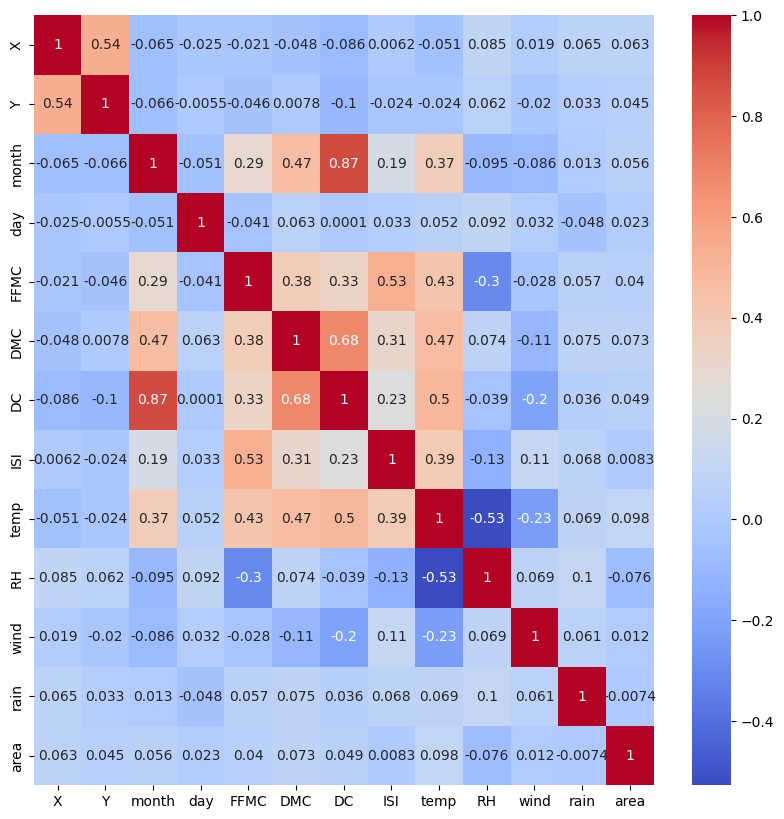

In [12]:
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [13]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(np.abs(upper[column]) > 0.9)]
df = df.drop(columns=to_drop)

#### ***4.2. Split data after feature engineering***

In [14]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
X_train, X_test = X[:slicing], X[slicing:]
y_train, y_test = y[:slicing], y[slicing:]

#### 4.3. Train and Evaluation

In [15]:
weight_engineer = fit(X_train, y_train)
y_pred_engineer = predict(weight_engineer, X_test)

rmse_engineer = rmse(y_test, y_pred_engineer)

print('Kết quả của bài toán hồi quy tuyến tính sau khi loại bỏ các biến có tương quan cao: ')
print('RMSE_Original:', rmse_org)
print('RMSE_Normalization:', rmse_norm)
print('RMSE_Engineering:', rmse_engineer)

Kết quả của bài toán hồi quy tuyến tính sau khi loại bỏ các biến có tương quan cao: 
RMSE_Original: 80.02441553024437
RMSE_Normalization: 80.02441553024424
RMSE_Engineering: 80.02441553024437


Sau khi `Featuring Engineering` lại và huấn luyện một lần nữa thì kết quả cho ra khác tương tự đối với kết quả của mô hình gốc. Nguyên nhân là vì không có cột nào có `Relation` mạnh đối với những cột khác nên không có cột có nguy cơ cao làm `det(X) = 0`.

### **5. Assignment 4 (2 scores):**

- Implement the Linear Regression model using Machine Learning libraries (Scikit Learn or Skorch).
- Compare the results of Linear Regression model constructed manually and from Machine Learning libraries.

In [16]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
rmse_lib = rmse(y_test, y_pred)

print('Kết quả của bài toán hồi quy tuyến tính sử dụng thư viện scikit-learn: ')
print('RMSE Sckit-learn: ', rmse_lib)
print('RMSE_Original:', rmse_org)
print('RMSE_Normalization:', rmse_norm)
print('RMSE_Engineering:', rmse_engineer)

Kết quả của bài toán hồi quy tuyến tính sử dụng thư viện scikit-learn: 
RMSE Sckit-learn:  80.02441553024424
RMSE_Original: 80.02441553024437
RMSE_Normalization: 80.02441553024424
RMSE_Engineering: 80.02441553024437


### **6. Nhận xét:**


**Kết quả tổng kết:**
- Kết quả gốc, sau khi `Standadization` và sau khi `Feature Engineering` không quá khác nhau với **RMSE ≈ 80.0244**.
- Đối với kết quả của thư viện `Scikit-learn` thì các kết quả cũng không khác nhiều.

⇒ Mô hình tự xây (chỉ sử dụng numpy) có kết quả tương tự với mô hình trong thư viện. Từ đây có thể nhận xét, mô hình triển khai thủ công triển khai khá đúng.